<a href="https://colab.research.google.com/github/wj-arit/CIFAR-10-classification/blob/experiment%2Falexnet/Alex_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets,transforms
from google.colab import drive
import matplotlib.pyplot as plt
import pandas as pd


drive.mount('/content/drive')



Mounted at /content/drive


50000
40000 10000
<class 'torchvision.datasets.cifar.CIFAR10'> <class 'torch.utils.data.dataset.Subset'>
torch.Size([3, 32, 32])
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
6


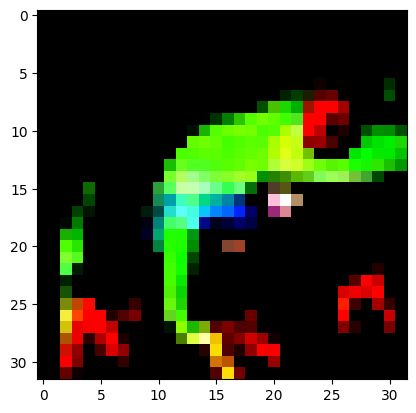

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32,4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), #convert np as tensor
    transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616)) # cifar-10 normalization
])

# validation setting
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
])

# test setting
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
])

full_train_dataset = datasets.CIFAR10('/content/drive/MyDrive/data',download=True,train=True,transform=train_transform)
full_test_dataset = datasets.CIFAR10('/content/drive/MyDrive/data',download=True,train=False,transform=test_transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# 스플릿 비율 고정
torch.manual_seed(42)
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset,(train_size,val_size))

# set batch size
train_batch_size = 64
val_batch_size = 1000
test_batch_size = 1000
# loader correspond to dataset
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=val_batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(full_test_dataset, batch_size=test_batch_size, shuffle=False)

if __name__ == '__main__':
    print(len(full_train_dataset))
    print(train_size, val_size)
    print(type(full_test_dataset),type(train_dataset))
    x1,y1 = train_dataset[0]
    x2,y2 = val_dataset[0]
    print(x1.shape)
    print(full_train_dataset.class_to_idx)
    print(y1)
    plt.imshow(x1.permute(1,2,0))
    plt.show()

In [ ]:
class AlexNet_BN(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet_BN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # [B, 64, 16, 16]

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # [B, 192, 8, 8]

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # [B, 256, 4, 4]
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(inplace=True),

            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x



In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
my_model = AlexNet_BN().to(device)
criterion = nn.CrossEntropyLoss()

# hyper parameters
learning_rate = 0.001
momentum = 0.9
epoch = 50
optimizer = torch.optim.Adam(my_model.parameters(),lr=learning_rate)

def train_one_epoch(my_model,train_dataloader,optimizer,criterion,device):
    my_model.train()
    total_correct = 0
    total_loss = 0.0
    total = len(train_dataset)
    for x_batch, y_batch in train_dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # logit(output)
        y_hat = my_model(x_batch)
        # loss(cross_entropy)
        loss = criterion(y_hat, y_batch)
        # initialize gradient
        optimizer.zero_grad()
        # backpropagation
        loss.backward()
        # update parameters
        optimizer.step()

        # calculate batch_loss
        batch_loss = loss.item() * x_batch.size(0)
        total_loss += batch_loss

        # prediction in train
        preds = torch.argmax(y_hat,dim=1) # indices of high probability
        batch_correct = torch.sum(preds==y_batch).item()
        total_correct += batch_correct
    epoch_loss = total_loss / total
    epoch_accuracy = total_correct / total
    #print(f'train epoch loss: {epoch_loss} train epoch accuracy: {epoch_accuracy}')

    return epoch_loss, epoch_accuracy


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    total = len(dataloader.dataset)
    total_loss = 0.0
    total_correct = 0
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_hat = model(x_batch)
            loss = criterion(y_hat, y_batch)
            batch_loss = loss.item() * x_batch.size(0)
            total_loss += batch_loss

            preds = torch.argmax(y_hat,1)
            correct = torch.sum(preds==y_batch).item()
            total_correct += correct

        val_loss = total_loss/total
        val_accuracy = total_correct/total
        #print(f'validation loss: {val_loss} validation accuracy: {val_accuracy}')
        return val_loss, val_accuracy



'''
if __name__ == '__main__':
    history = {
        'epoch': [],
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    best_val_loss = [0, float('inf')]
    count = 0
    for epo in range(4):
        if epo == 0:
            print(f'device: {device}')
        # best val_loss compare
        train_loss, train_accuracy = train_one_epoch(
            my_model,
            train_dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss, val_accuracy = validate_one_epoch(
            my_model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )
        # result saving
        history['epoch'].append(epo + 1)
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)

        # extract best model
        if val_loss <= best_val_loss[1]:
            best_val_loss[0] = epo + 1
            best_val_loss[1] = val_loss
            count += 1

            # save model
            save_model_path = f'/content/drive/MyDrive/Alex_net_best/best_model.pth'
            torch.save(my_model.state_dict(), save_model_path)
            print('save model complete')
            print(f'model change number: {count}')
            print(val_loss)
    df = pd.DataFrame(history)
    df.to_pickle('/content/drive/MyDrive/Alex_net_log/training_log.pkl')
    df.to_csv('/content/drive/MyDrive/Alex_net_log/training_log.csv', index=False)
    print('history saving complete')
'''

"\nif __name__ == '__main__':\n    history = {\n        'epoch': [],\n        'train_loss': [],\n        'train_accuracy': [],\n        'val_loss': [],\n        'val_accuracy': []\n    }\n    best_val_loss = [0, float('inf')]\n    count = 0\n    for epo in range(4):\n        if epo == 0:\n            print(f'device: {device}')\n        # best val_loss compare\n        train_loss, train_accuracy = train_one_epoch(\n            my_model,\n            train_dataloader=train_loader,\n            optimizer=optimizer,\n            criterion=criterion,\n            device=device\n        )\n\n        val_loss, val_accuracy = validate_one_epoch(\n            my_model,\n            dataloader=val_loader,\n            criterion=criterion,\n            device=device\n        )\n        # result saving\n        history['epoch'].append(epo + 1)\n        history['train_loss'].append(train_loss)\n        history['train_accuracy'].append(train_accuracy)\n        history['val_loss'].append(val_loss)\n 

In [ ]:
history = {
        'epoch': [],
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
best_val_loss = [0,float('inf')]
count = 0

#training
for epo in range(epoch):
    if epo == 0:
        print(f'device: {device}')
    # best val_loss compare
    train_loss, train_accuracy = train_one_epoch(
        my_model=my_model,
        train_dataloader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )

    val_loss, val_accuracy = validate_one_epoch(
        model=my_model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )
    # result saving
    history['epoch'].append(epo+1)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)

    print('-'*80)
    print(f'epoch: {epo+1} train_loss: {train_loss:4f} val_loss: {val_loss:4f} train_accuracy: {train_accuracy:4f} val_accuracy: {val_accuracy:4f}')

# extract best model
    if val_loss <= best_val_loss[1]:
        best_val_loss[0] = epo + 1
        best_val_loss[1] = val_loss
        count += 1

        # save model
        save_model_path = f'/content/drive/MyDrive/Alex_net_best/best_model.pth'
        torch.save(my_model.state_dict(), save_model_path)
        print('save model complete')
        print(f'model change number: {count}')
        print(val_loss)
df = pd.DataFrame(history)
df.to_pickle('/content/drive/MyDrive/Alex_net_log/training_log.pkl')
df.to_csv('/content/drive/MyDrive/Alex_net_log/training_log.csv', index=False)
print('history saving complete')

device: cuda
--------------------------------------------------------------------------------
epoch: 1 train_loss: 1.655699 val_loss: 1.318315 train_accuracy: 0.425275 val_accuracy: 0.529100
save model complete
model change number: 1
1.3183151245117188
--------------------------------------------------------------------------------
epoch: 2 train_loss: 1.178785 val_loss: 1.080327 train_accuracy: 0.586850 val_accuracy: 0.614000
save model complete
model change number: 2
1.0803265213966369
--------------------------------------------------------------------------------
epoch: 3 train_loss: 0.963284 val_loss: 0.967581 train_accuracy: 0.661075 val_accuracy: 0.662200
save model complete
model change number: 3
0.9675807237625123
--------------------------------------------------------------------------------
epoch: 4 train_loss: 0.852082 val_loss: 0.915987 train_accuracy: 0.703050 val_accuracy: 0.685200
save model complete
model change number: 4
0.9159868657588959
---------------------------

   epoch  train_loss  train_accuracy  val_loss  val_accuracy
0      1    1.655699        0.425275  1.318315        0.5291
1      2    1.178785        0.586850  1.080327        0.6140
2      3    0.963284        0.661075  0.967581        0.6622
3      4    0.852082        0.703050  0.915987        0.6852
4      5    0.756843        0.737275  0.757329        0.7354
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   epoch           50 non-null     int64  
 1   train_loss      50 non-null     float64
 2   train_accuracy  50 non-null     float64
 3   val_loss        50 non-null     float64
 4   val_accuracy    50 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 2.1 KB
None


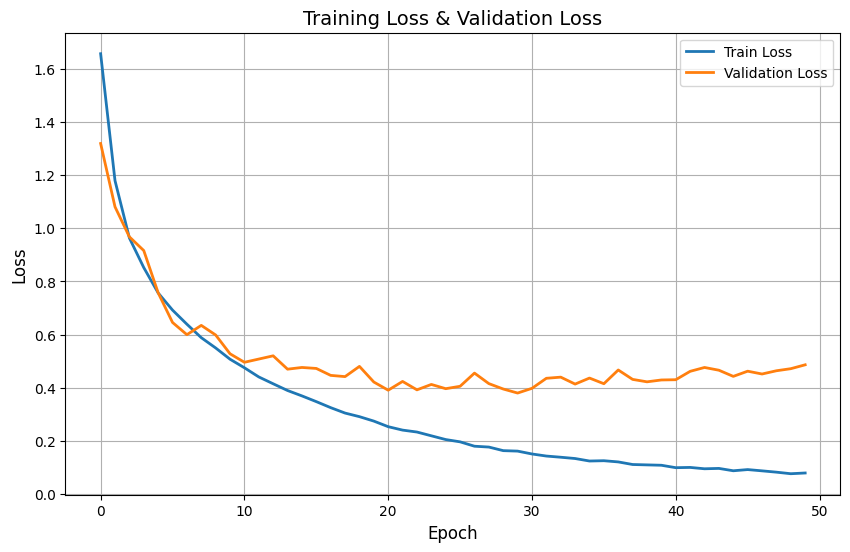

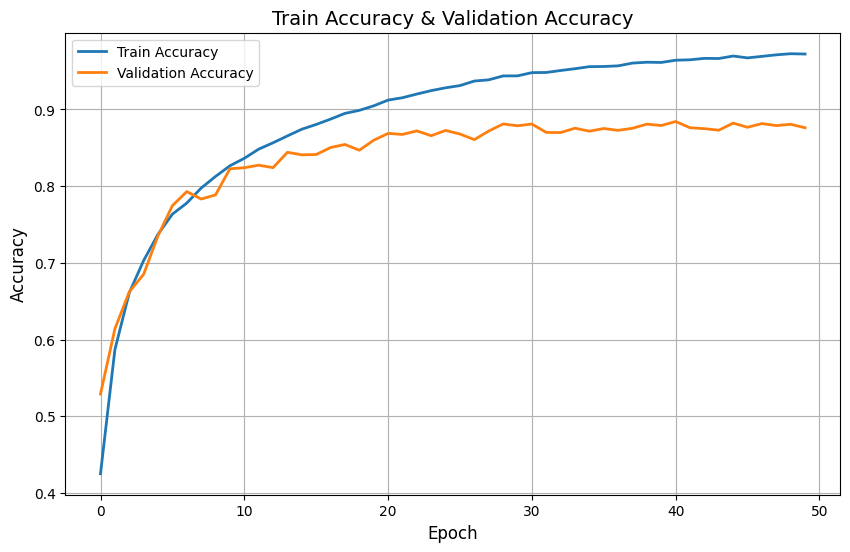

In [ ]:
df = pd.read_pickle('/content/drive/MyDrive/Alex_net_log/training_log.pkl')
print(df.head())
print(df.info())

# plot loss graph
plt.figure(figsize=(10,6))
plt.plot(df['train_loss'], label='Train Loss', linewidth=2)
plt.plot(df['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Training Loss & Validation Loss', fontsize=14)
plt.xlabel('Epoch',fontsize=12)
plt.ylabel('Loss',fontsize=12)
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Alex_net_log/train_val_loss.png')
plt.show()

#plot accuracy graph
plt.figure(figsize=(10,6))
plt.plot(df['train_accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(df['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title('Train Accuracy & Validation Accuracy', fontsize=14)
plt.xlabel('Epoch',fontsize=12)
plt.ylabel('Accuracy',fontsize=12)
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Alex_net_log/train_val_accuracy.png')
plt.show()

In [ ]:
# model load
device = 'cuda' if torch.cuda.is_available() else 'cpu'
best_model_path ='/content/drive/MyDrive/Alex_net_best/best_model.pth'
load_model = AlexNet_BN().to(device)
state_dict = torch.load(best_model_path,map_location=device)
load_model.load_state_dict(state_dict)


# test
total = len(test_loader.dataset)
total_correct = 0
#total_loss = 0.0
load_model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # output logits
        y_hat = load_model(x_batch)
        # loss
        #loss = nn.CrossEntropyLoss(y_hat,y_batch)
        #batch_loss = loss.item() * x_batch.size(0)
        #total_loss += batch_loss

        # accuracy
        preds = torch.argmax(y_hat,dim=1)
        batch_correct = torch.sum(preds==y_batch).item()
        total_correct += batch_correct
test_accuracy = total_correct / total
print(f'correct: {total_correct}/{total} test_accuracy: {test_accuracy * 100:.3f}')

correct: 8858/10000 test_accuracy: 88.580
